# IDR0133 Dahlin → AnnData

Builds an AnnData object from [idr0133-dahlin-cellpainting](https://idr.openmicroscopy.org/webclient/?show=screen-3151) in the [Image Data Resource](https://idr.openmicroscopy.org/), a Cell Painting screen of kinase inhibitors and other bioactives in U2OS.

IDR stores its per-well data as one ISA-Tab annotation table rather than the per-plate profile files the Cell Painting Gallery uses, and this is the only Cell Painting study there that puts CellProfiler features in it.
The table mixes 372 features with experimental annotation and two derived statistics, so features are separated by name rather than by prefix.

The annotation table lives in the study's GitHub repository, which avoids pulling anything from the IDR servers:

```bash
curl -LO https://raw.githubusercontent.com/IDR/idr0133-dahlin-cellpainting/main/screenA/idr0133-screenA-annotation.csv.zip
unzip idr0133-screenA-annotation.csv.zip
```

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc

import cell_painting_io as cpio

ANNOTATION = Path("~/data/idr0133-dahlin-cellpainting/idr0133-screenA-annotation.csv").expanduser()

## Separating features from annotation

Every column that is not a CellProfiler measurement is treated as metadata, including the numeric ones.
`Compound Concentration`, `Mahalanobis distance` and `Relative well cellcount` would otherwise be read as features: they are numbers, but they describe the well rather than the cells in it.

Three wells are blank across every feature. They have to be dropped as wells first: because each of the 372 features is missing in those three rows, filtering on incomplete *features* would otherwise discard the entire matrix.

In [2]:
columns = pd.read_csv(ANNOTATION, nrows=0).columns
features = [c for c in columns if re.match(r"^(Cells|Nuclei|Cytoplasm|Image)_", c)]
annotation = [c for c in columns if c not in features]
print(f"{len(features)} features, {len(annotation)} annotation columns")
print(annotation[-6:])

372 features, 31 annotation columns
['Comment [Image File Path]', 'Comment [Image Prefix]', 'Mahalanobis distance', 'Mahalanobis distance significant', 'Relative well cellcount', 'Relative well cellcount significant']


In [3]:
adata = cpio.read_profiles(
    ANNOTATION,
    metadata_columns=annotation,
    index_columns=("Plate", "Well"),
)
cpio.annotate_features(adata.var)
adata = cpio.drop_incomplete_wells(adata)
adata = cpio.drop_constant_features(cpio.drop_extreme_features(cpio.drop_incomplete_features(adata)))


def present(columns):
    return [c for c in columns if c in adata.obs.columns and adata.obs[c].nunique() > 1]


for column in present(
    ["Plate", "Compound Class", "Compound Name", "Control Type", "Experimental Condition [Treatment time (h)]"]
):
    adata.obs[column] = adata.obs[column].astype("category")
adata

AnnData object with n_obs × n_vars = 23108 × 372
    obs: 'Plate', 'Well', 'Characteristics [Organism]', 'Term Source 1 REF', 'Term Source 1 Accession', 'Characteristics [Cell Line]', 'Term Source 2 REF', 'Term Source 2 Accession', 'Experimental Condition [Treatment time (h)]', 'Experimental Condition [Experimental Batch]', 'Compound Manuscript Number', 'Compound BRD', 'Compound BRD (short)', 'Compound Name', 'Compound Class', 'Compound Purity (%)', 'Compound Concentration (microMolar)', 'Compound IUPAC', 'Compound SMILES', 'Compound InChIKey', 'Compound Unichem URL', 'Compound PubChem CID', 'Compound PubChem URL', 'Control Type', 'Channels', 'Comment [Image File Path]', 'Comment [Image Prefix]', 'Mahalanobis distance', 'Mahalanobis distance significant', 'Relative well cellcount', 'Relative well cellcount significant'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    layers: None (.X)

## Sanity checks

In [4]:
print(f"{adata.n_obs:,} wells x {adata.n_vars:,} features across {adata.obs['Plate'].nunique()} plates")
print(f"non-finite: {int((~np.isfinite(adata.X)).sum())} | max|x|: {np.abs(adata.X).max():.1f}")
for column in present(["Compound Class", "Control Type", "Experimental Condition [Treatment time (h)]"]):
    print(f"\n{column}:")
    print(adata.obs[column].value_counts(dropna=False).head(6).to_string())

23,108 wells x 372 features across 84 plates
non-finite: 0 | max|x|: 155.3

Compound Class:
Compound Class
Solvent control             9855
Historical KAT inhibitor    1807
Cytoskeletal                1472
Nonspecific electrophile    1360
CDRP-NC                     1328
Miscellaneous               1231

Control Type:
Control Type
<NA>        11133
Negative     9855
Positive     2120

Experimental Condition [Treatment time (h)]:
Experimental Condition [Treatment time (h)]
24    14310
48     8798


In [5]:
adata.write_h5ad(ANNOTATION.with_name("idr0133.h5ad"))

## UMAP

The published features are already normalized, so they enter PCA unscaled.

Concentration is left numeric rather than categorical: it is a dose, and the 92 distinct values render as a colour bar instead of an unreadable legend.

In [6]:
sc.pp.pca(adata, n_comps=50)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.umap(adata)

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


How often do neighbouring wells share a label, against the rate expected if labels were shuffled?

In [7]:
cpio.neighbour_enrichment(
    adata,
    present(
        [
            "Plate",
            "Compound Class",
            "Compound Concentration (microMolar)",
            "Experimental Condition [Treatment time (h)]",
        ]
    ),
)

,observed,baseline,ratio
covariate,,,
Plate,0.064,0.012,5.318
Compound Class,0.552,0.210,2.631
Compound Concentration (microMolar),0.270,0.118,2.287
Experimental Condition [Treatment time (h)],0.702,0.528,1.329


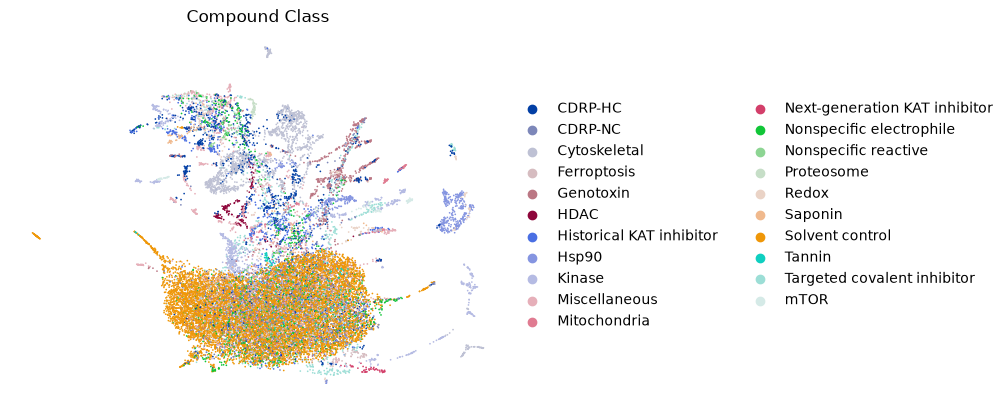

In [8]:
sc.pl.umap(adata, color="Compound Class", frameon=False, size=6)

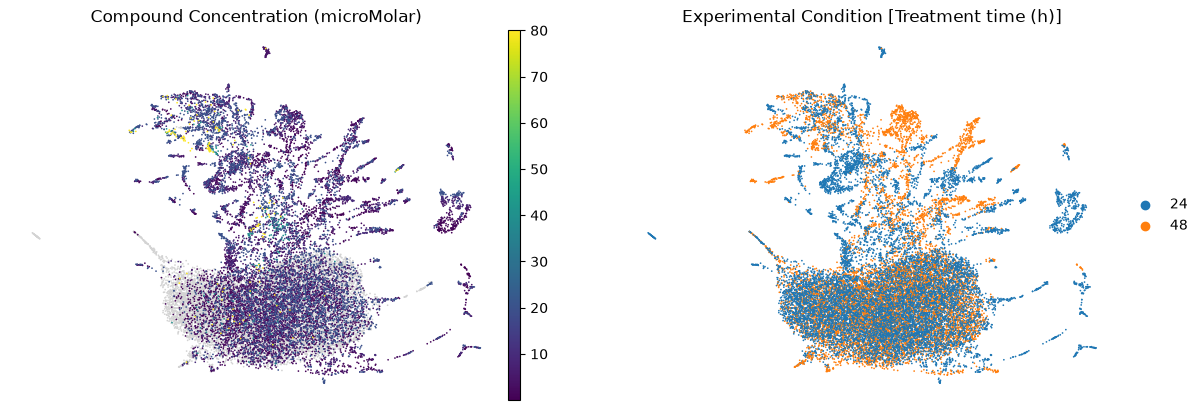

In [9]:
sc.pl.umap(
    adata,
    color=["Compound Concentration (microMolar)", "Experimental Condition [Treatment time (h)]"],
    ncols=2,
    frameon=False,
    size=6,
)